# Lecture 17 · Patchify & patch embedding (ViT)

**Goal** · turn an image into a sequence of tokens the way a Vision Transformer does. Take a toy $8\times8$ image, cut it into non-overlapping $4\times4$ patches, flatten each patch to a vector, and linearly project to an embedding dimension $d$. Follow the shape pipeline with real numbers:

$$H\times W\times C \;\to\; N \text{ patches} \times (P^2C) \;\to\; N \times d,\qquad (8,8,1)\to(4,16)\to(4,8).$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

## 1 · A toy image

We use an $8\times8$ grayscale image whose pixels are $0..63$ — a plain ramp, so we can *read off* which pixels land in which patch.

image shape (H, W) = (8, 8)


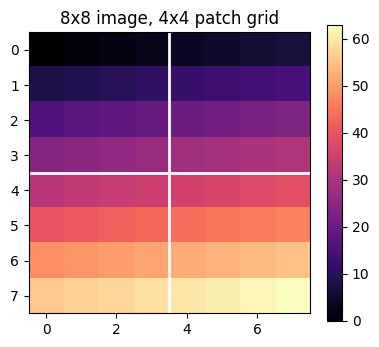

In [2]:
H, W, C = 8, 8, 1
P = 4                                    # patch size
img = np.arange(H * W).reshape(H, W).astype(float)   # values 0..63
print('image shape (H, W) =', img.shape)

plt.figure(figsize=(4, 4))
plt.imshow(img, cmap='magma')
for k in range(P, W, P):
    plt.axvline(k - 0.5, color='w', lw=2)
for k in range(P, H, P):
    plt.axhline(k - 0.5, color='w', lw=2)
plt.title(f'{H}x{W} image, {P}x{P} patch grid'); plt.colorbar(shrink=0.8)
plt.tight_layout(); plt.show()

## 2 · Patchify: $H\times W\times C \to N \times (P^2C)$

Split the height into $(n_h, P)$ and the width into $(n_w, P)$, regroup so each patch is contiguous, then flatten each patch to a $P^2C$-vector. Here $n_h=n_w=2$, so $N=4$ patches, each of length $4\cdot4\cdot1=16$.

In [3]:
def patchify(image, P):
    H, W, C = image.shape
    nh, nw = H // P, W // P
    p = image.reshape(nh, P, nw, P, C)       # split H->(nh,P), W->(nw,P)
    p = p.transpose(0, 2, 1, 3, 4)           # (nh, nw, P, P, C)  -> patches contiguous
    return p.reshape(nh * nw, P * P * C)      # (N, P^2 C)

img3 = img.reshape(H, W, C)
patches = patchify(img3, P)
N = patches.shape[0]
print(f'{H}x{W}x{C}  ->  {N} patches x {P*P*C}      patches.shape =', patches.shape)
print('\npatch 0 (top-left 4x4 block) flattened:')
print(patches[0].astype(int))
print('hand-check: rows 0-3, cols 0-3 =', [0,1,2,3,8,9,10,11,16,17,18,19,24,25,26,27])

8x8x1  ->  4 patches x 16      patches.shape = (4, 16)

patch 0 (top-left 4x4 block) flattened:
[ 0  1  2  3  8  9 10 11 16 17 18 19 24 25 26 27]
hand-check: rows 0-3, cols 0-3 = [0, 1, 2, 3, 8, 9, 10, 11, 16, 17, 18, 19, 24, 25, 26, 27]


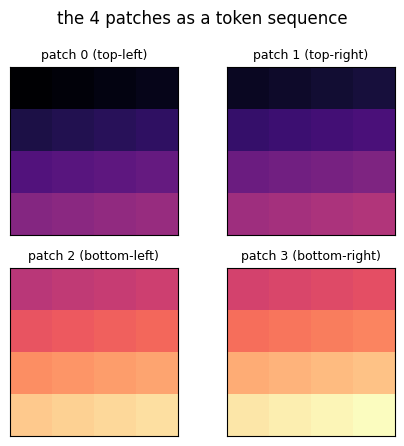

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(4.5, 4.5))
titles = ['patch 0 (top-left)', 'patch 1 (top-right)',
          'patch 2 (bottom-left)', 'patch 3 (bottom-right)']
for i, ax in enumerate(axes.ravel()):
    ax.imshow(patches[i].reshape(P, P), cmap='magma', vmin=0, vmax=63)
    ax.set_title(titles[i], fontsize=9); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('the 4 patches as a token sequence'); plt.tight_layout(); plt.show()

## 3 · Linear projection: $N\times(P^2C) \to N\times d$

Each flattened patch is projected by a *shared* weight $W_e\in\mathbb{R}^{P^2C\times d}$ (here random and fixed) to an embedding of size $d=8$. This is exactly the "patch embedding" linear layer in ViT.

In [5]:
d = 8
W_e = 0.02 * np.random.randn(P * P * C, d)     # fixed random projection (16 -> 8)
tokens = patches @ W_e                          # (N, d)
print('patches', patches.shape, '@ W_e', W_e.shape, '->  tokens', tokens.shape)
print('\npipeline:  (8,8,1) -> (4,16) -> (4,8)')
print('token 0 =', np.round(tokens[0], 3))

patches (4, 16) @ W_e (16, 8) ->  tokens (4, 8)

pipeline:  (8,8,1) -> (4,16) -> (4,8)
token 0 = [-1.653  1.769 -1.158  1.137  1.871  0.72   0.676  2.458]


## 4 · Add a (learned) position embedding

Projection alone is *permutation-blind*: shuffle the patches and the token set is identical. A position embedding $E_{pos}\in\mathbb{R}^{N\times d}$ (learned; here random-fixed) is added so each token knows *where* it came from.

In [6]:
E_pos = 0.02 * np.random.randn(N, d)
tokens_pos = tokens + E_pos
print('tokens + position embedding -> shape', tokens_pos.shape)
print('token 0 before pos:', np.round(tokens[0], 3))
print('token 0 after  pos:', np.round(tokens_pos[0], 3))
print('position info now distinguishes otherwise-similar patches.')

tokens + position embedding -> shape (4, 8)
token 0 before pos: [-1.653  1.769 -1.158  1.137  1.871  0.72   0.676  2.458]
token 0 after  pos: [-1.64   1.778 -1.173  1.148  1.858  0.721  0.663  2.471]
position info now distinguishes otherwise-similar patches.


## Takeaway

- **Patchify** reshapes an image into $N=(H/P)(W/P)$ non-overlapping patches, each flattened to a $P^2C$-vector: $(8,8,1)\to(4,16)$.
- A single shared **linear projection** maps every patch to a $d$-dim token: $(4,16)\to(4,8)$ — turning an image into a short sequence a Transformer can consume.
- A **position embedding** is added back because the projection itself ignores patch order.